In [15]:
import math
from typing import Literal, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from vinesforest import VinesForest

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import importlib

datasets = {
  "power": "power/data.npy",
  "gas": "gas/ethylene_CO.csv",
  "hepmass": "hepmass",
  "miniboone": "miniboone/data.npy",
}
dataset = "power"

# (1659917, 6)
# (852174, 8)
# (315123, 21)
# (29556, 43)

if dataset not in datasets:
  raise ValueError(f"Dataset {dataset} not in {datasets}")

# Dynamically import module
module = importlib.import_module(f"uci.{dataset}")

# Dynamically get class
cls = getattr(module, dataset.upper())

# Instantiate
data = cls(f"uci/data/{datasets[dataset]}")

In [17]:
x_trn = data.trn.x
x_val = data.val.x
x_tst = data.tst.x

In [18]:
print(pd.DataFrame(x_trn).describe())
print(pd.DataFrame(x_tst).describe())

               0          1          2          3          4          5
count  1.660e+06  1.660e+06  1.660e+06  1.660e+06  1.660e+06  1.660e+06
mean  -3.915e-04  8.359e-05 -2.693e-04 -1.852e-04 -1.138e-04 -1.973e-04
std    9.996e-01  9.999e-01  9.992e-01  9.998e-01  1.000e+00  1.000e+00
min   -9.608e-01 -5.446e+00 -2.633e-01 -3.085e-01 -8.240e-01 -1.732e+00
25%   -7.407e-01 -5.714e-01 -2.190e-01 -2.474e-01 -7.528e-01 -8.670e-01
50%   -4.642e-01  5.227e-02 -1.747e-01 -1.862e-01 -6.623e-01  3.214e-04
75%    4.130e-01  6.317e-01 -1.305e-01 -9.164e-02  1.298e+00  8.664e-01
max    9.490e+00  4.108e+00  1.419e+01  1.355e+01  2.966e+00  1.731e+00
                0          1           2          3           4           5
count  204928.000  2.049e+05  204928.000  2.049e+05  204928.000  204928.000
mean        0.004  2.175e-04       0.003 -5.027e-04       0.003       0.003
std         1.003  1.001e+00       1.010  9.988e-01       1.001       1.000
min        -0.959 -5.070e+00      -0.263 -3.085e

In [19]:
def grid_size_2d(n: int, h: Optional[float] = None, c: float = 0.7) -> int:
  """
  Compute the number of grid points per axis for a 2D KDE table
  with bilinear interpolation.

  Parameters
  ----------
  n : int
      Sample size.
  h : float or None, optional
      Bandwidth. If None, uses rule-of-thumb h ~ n^(-1/6).
  c : float, optional
      Safety constant (< 1). Default 0.7.

  Returns
  -------
  m : int
      Grid size per axis.
  """
  if h is None:
    # rule-of-thumb bandwidth for 2D
    h = n ** (-1 / 6)

  # grid spacing Δ = c * h * (n h^2)^(-1/4)
  delta = c * h * (n * h**2) ** (-0.25)

  # number of intervals on [0,1]
  m = math.ceil(1.0 / delta)
  return m


def grid_size_1d(
  n: int, h: Optional[float] = None, c: float = 0.7, length: float = 1.0
) -> int:
  """
  Number of grid points for a 1D KDE lookup table over an interval of length `length`,
  using linear interpolation.

  Rule: Δ = c * h * (n*h)^(-1/4)  (variance-matched),
        or Δ = min(Δ, c*h*h)      (cap by bias-matched spacing).

  Parameters
  ----------
  n : int
      Sample size.
  h : float or None
      Bandwidth. If None, uses 1D rate-optimal h ~ n^(-1/5).
  c : float
      Safety factor in (0,1]; smaller -> finer grid. Default 0.7.
  length : float
      Interval length (domain width). Default 1.0.

  Returns
  -------
  m : int
      Grid size (number of knots) across the interval.
  """
  if h is None:
    h = n ** (-1 / 5)  # rate-optimal scaling in 1D

  delta_var = c * h * (n * h) ** (-0.25)  # match stochastic error
  delta_bias = c * h * h  # match bias (if bias-dominated)
  delta = min(delta_var, delta_bias)

  m = max(2, math.ceil(length / delta))
  return m


def grid_size_1d_many(
  n: int,
  lengths: Sequence[float],
  h: Optional[float] = None,
  mode: Literal["rate", "bandwidth_steps"] = "bandwidth_steps",
  # parameters for "rate" mode
  c: float = 0.7,
  # parameters for "bandwidth_steps" mode
  K_min: int = 8,
  K_max: int = 16,
  grow_with_n: bool = True,
  # global caps
  m_cap: Optional[int] = 2048,
) -> list[int]:
  """
  Compute grid sizes per axis for 1D KDE lookup tables over given axis lengths.

  Parameters
  ----------
  n : int
      Sample size.
  lengths : Sequence[float]
      Interval lengths per feature, e.g. max - min for each column.
  h : float or None
      Bandwidth. If None, uses 1D rate-optimal scaling h ~ n^(-1/5).
      (You can pass your plug-in/Silverman bandwidth if available.)
  mode : {"rate","bandwidth_steps"}
      "rate":   Δ = c * h * (n*h)^(-1/4)   (theoretical, can be large for big n)
      "bandwidth_steps": choose Δ = h / K with K in [K_min, K_max],
                         optionally slowly growing with n.
  c : float
      Safety factor for "rate" mode (smaller -> finer grid).
  K_min, K_max : int
      Min/max steps per bandwidth for "bandwidth_steps" mode.
  grow_with_n : bool
      If True, use K = min(K_max, K_min * n**0.1) (very slow growth in n).
  m_cap : int or None
      Hard cap on grid size per axis (None to disable).

  Returns
  -------
  list[int]
      Grid size per axis.
  """
  if h is None:
    h = n ** (-1 / 5)  # rate-optimal scaling in 1D

  if mode == "rate":
    delta = c * h * (n * h) ** (-0.25)  # match stochastic term
    # (Bias-matched spacing equals this at h ~ n^(-1/5); you could do: delta = min(delta, c*h*h))
    m_list = [max(2, math.ceil(L / delta)) for L in lengths]
  else:
    # steps per bandwidth; grow very slowly with n (n**0.1) but clamp to K_max
    K = K_min * (n**0.1) if grow_with_n else K_min
    K = max(K_min, min(int(round(K)), K_max))
    delta = h / K
    m_list = [max(2, math.ceil(L / delta)) for L in lengths]

  if m_cap is not None:
    m_list = [min(m, m_cap) for m in m_list]
  return m_list


class Uniform:
  def __init__(self, xmin=0, xmax=1, type="continuous"):
    if type != "continuous":
      raise ValueError("Uniform distribution only supports continuous type.")
    self.xmin = xmin
    self.xmax = xmax
    self.type = type

  def fit(self, x):
    pass

  def cdf(self, x):
    return np.clip((x - self.xmin) / (self.xmax - self.xmin), 0, 1)

  def pdf(self, u):
    return np.where(
      (u >= self.xmin) & (u <= self.xmax), 1 / (self.xmax - self.xmin), 0
    )


lengths = [
  float(x_trn[:, i].max() - x_trn[:, i].min()) for i in range(x_trn.shape[1])
]

grid_sizes_1d = [
  grid_size_1d(x_trn.shape[0], c=0.7, length=lengths[i])
  for i in range(x_trn.shape[1])
]
grid_sizes_1d_cap = grid_size_1d_many(x_trn.shape[0], lengths=lengths)
print("Grid sizes:", grid_sizes_1d)
print("Grid sizes (capped):", grid_sizes_1d_cap)

Grid sizes: [4593, 4199, 6354, 6091, 1666, 1522]
Grid sizes (capped): [2048, 2048, 2048, 2048, 1064, 972]


In [30]:
np.log(1 / (x_trn[:, 5].max() - x_trn[:, 5].min()))

np.float32(-1.2419679)

In [20]:
# grid_size = [
#   grid_size_1d(
#     x_trn.shape[0], c=0.7, length=float(x_trn[:, i].max() - x_trn[:, i].min())
#   )
#   for i in range(x_trn.shape[1])
# ]
grid_size = [2000] * 6
multiplier = [1e-2] * 6
margins_controls = {
  0: {
    "kde": {
      "xmin": x_trn[:, 0].min(),
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[0],
      "multiplier": multiplier[0],
    }
  },
  1: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[1],
      "multiplier": multiplier[1],
    }
  },
  2: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[2],
      "multiplier": multiplier[2],
    }
  },
  3: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[3],
      "multiplier": multiplier[3],
    }
  },
  4: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[4],
      "multiplier": multiplier[4],
    }
  },
  5: {
    "kde": {
      "type": "continuous",
      "degree": 0,
      "grid_size": grid_size[5],
      "multiplier": multiplier[5],
    }
  },
  # 5: {
  #   "uniform": {
  #     "xmin": x_trn[:, 5].min(),
  #     "xmax": x_trn[:, 5].max(),
  #     "type": "continuous",
  #   }
  # },
}


# margins_controls = {
#   0: {"kde": {"xmin": 0, "type": "continuous"}},
#   1: {"kde": {"type": "continuous"}},
#   2: {"kde": {"xmin": 0, "xmax": 88, "type": "discrete"}},
#   3: {"kde": {"xmin": 0, "xmax": 80, "type": "discrete"}},
#   4: {"kde": {"xmin": 0, "xmax": 31, "type": "discrete"}},
#   # 5: {"uniform": {"xmin": 0, "xmax": 1440, "type": "continuous"}},
# }

d = x_trn.shape[1]
margins = [
  pv.Kde1d(**margins_controls[i]["kde"])
  if "kde" in margins_controls[i]
  else Uniform(**margins_controls[i]["uniform"])
  for i in range(d)
]
for i in range(d):
  margins[i].fit(x_trn[:, i])

margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
)
margins_loglik.mean(axis=0)

array([-0.6806185 , -1.4015606 ,  1.35255343,  0.7445599 ,  0.49531944,
       -1.2426559 ])

In [21]:
u_trn = np.column_stack([margins[i].cdf(x_trn[:, i]) for i in range(d)])
u_val = np.column_stack([margins[i].cdf(x_val[:, i]) for i in range(d)])
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 0')

(array([4.94801105e-01, 1.68834055e+00, 1.66405377e+00, 6.95924697e-01,
        3.01073756e-01, 2.04207199e-01, 1.62627997e-01, 1.59267204e-01,
        1.30629198e-01, 1.11162565e-01, 2.74488066e-01, 6.34762657e-01,
        5.90757209e-01, 3.58667020e-01, 2.47521466e-01, 1.98690692e-01,
        1.62530001e-01, 1.36249502e-01, 1.15001721e-01, 1.00152376e-01,
        1.09242988e-01, 1.07432936e-01, 9.29350130e-02, 8.26744198e-02,
        7.07476750e-02, 6.22796285e-02, 5.42842708e-02, 4.58046953e-02,
        4.07664317e-02, 3.98787921e-02, 3.96539767e-02, 4.38678242e-02,
        4.42079296e-02, 3.78842761e-02, 3.14107456e-02, 2.69316698e-02,
        2.20837890e-02, 1.84463913e-02, 1.75874410e-02, 1.48436143e-02,
        1.38001750e-02, 1.20708848e-02, 1.08948750e-02, 1.04683509e-02,
        9.47681189e-03, 8.58908134e-03, 7.66103435e-03, 6.58302585e-03,
        5.87403612e-03, 5.94321024e-03, 5.66651374e-03, 5.04390059e-03,
        4.82489522e-03, 3.86798649e-03, 3.10704276e-03, 2.841903

(array([4.86976455e-01, 1.62889056e+00, 1.73062273e+00, 8.12440408e-01,
        3.49473825e-01, 2.16741107e-01, 1.63842955e-01, 1.54791848e-01,
        1.39941370e-01, 1.09047974e-01, 1.58965158e-01, 4.72396971e-01,
        6.80954055e-01, 4.79984235e-01, 3.03567627e-01, 2.27580872e-01,
        1.89479097e-01, 1.57935380e-01, 1.30673215e-01, 1.05525052e-01,
        9.96175617e-02, 1.12733425e-01, 1.09969288e-01, 9.39266781e-02,
        8.29241056e-02, 7.08379505e-02, 6.42255328e-02, 5.89140541e-02,
        4.70988363e-02, 4.39551959e-02, 4.05949694e-02, 3.82643259e-02,
        4.44429847e-02, 4.60690574e-02, 4.30880157e-02, 3.28445280e-02,
        3.05681017e-02, 2.47688342e-02, 2.30345287e-02, 1.94573555e-02,
        1.59886347e-02, 1.42543423e-02, 1.43626719e-02, 1.17611313e-02,
        1.20863239e-02, 1.04061623e-02, 9.37643049e-03, 8.99699447e-03,
        6.88324275e-03, 6.55806581e-03, 6.07026133e-03, 5.63669810e-03,
        5.52827371e-03, 4.39009971e-03, 5.04048485e-03, 3.848112

Text(0.5, 0, 'Variable 0')

Text(0, 0.5, 'Density')

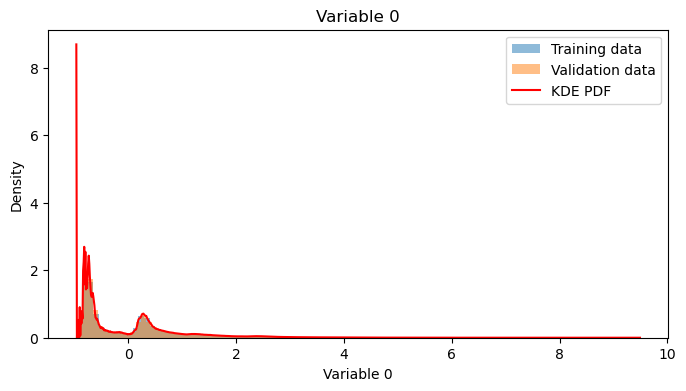

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 1')

(array([1.26114400e-05, 0.00000000e+00, 1.26114400e-05, 1.89171599e-05,
        7.56686397e-05, 6.93629197e-05, 2.01783039e-04, 3.08980279e-04,
        3.97260358e-04, 6.17960558e-04, 6.99934917e-04, 8.19743597e-04,
        1.02152664e-03, 1.29267260e-03, 1.46923275e-03, 1.19178108e-03,
        1.57642999e-03, 2.03674755e-03, 2.59165091e-03, 3.23483435e-03,
        3.65730846e-03, 4.65362134e-03, 5.88323674e-03, 7.16960361e-03,
        8.61361349e-03, 1.06125267e-02, 1.30906747e-02, 1.64642349e-02,
        1.87469055e-02, 2.22339686e-02, 2.61182921e-02, 3.02926788e-02,
        3.43850910e-02, 3.96125329e-02, 4.47769176e-02, 5.11015547e-02,
        6.05916633e-02, 6.79315213e-02, 7.87016910e-02, 8.72207187e-02,
        9.76692967e-02, 1.07922128e-01, 1.19581674e-01, 1.34381198e-01,
        1.47099836e-01, 1.64062222e-01, 1.89499497e-01, 2.12073974e-01,
        2.35178132e-01, 2.60968527e-01, 2.91412543e-01, 3.22600634e-01,
        3.56487573e-01, 3.89769163e-01, 4.18832227e-01, 4.361098

(array([2.49619851e-04, 4.36837136e-04, 4.36834739e-04, 4.36837136e-04,
        5.61644664e-04, 8.73674272e-04, 8.73669477e-04, 1.56013263e-03,
        1.18569429e-03, 1.37291295e-03, 1.49772321e-03, 9.36077009e-04,
        2.68342076e-03, 2.62100843e-03, 3.93153423e-03, 2.93303325e-03,
        5.05482972e-03, 5.42923175e-03, 7.05178013e-03, 8.48709821e-03,
        1.04216574e-02, 1.21690011e-02, 1.47900167e-02, 1.62877400e-02,
        1.93455915e-02, 2.19042020e-02, 2.27778114e-02, 2.65845870e-02,
        3.33243415e-02, 3.28875056e-02, 4.15618192e-02, 4.53061272e-02,
        5.52285435e-02, 6.27171596e-02, 6.55253906e-02, 8.04402176e-02,
        9.02378236e-02, 8.98631462e-02, 1.04403789e-01, 1.15823929e-01,
        1.24747863e-01, 1.39288259e-01, 1.56137645e-01, 1.70241205e-01,
        1.94329587e-01, 2.18105943e-01, 2.29151023e-01, 2.61415823e-01,
        2.81696002e-01, 3.10466393e-01, 3.46597163e-01, 3.65071035e-01,
        4.03884918e-01, 4.19610969e-01, 4.48007686e-01, 4.541833

Text(0.5, 0, 'Variable 1')

Text(0, 0.5, 'Density')

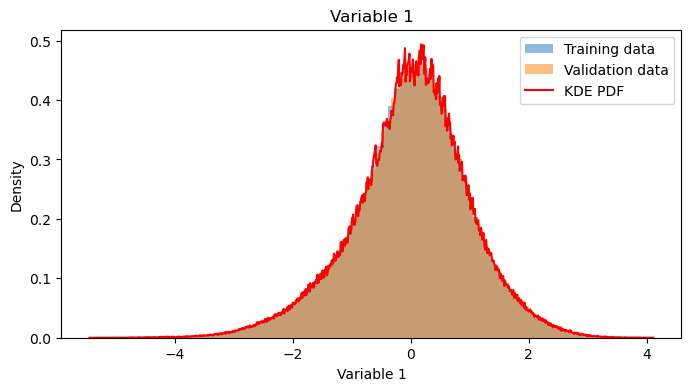

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 2')

(array([5.64616348e+00, 9.23413671e-01, 1.06739898e-01, 2.25939382e-02,
        1.41680911e-03, 1.35430310e-03, 1.18345280e-03, 1.12927974e-03,
        1.31679851e-03, 1.44181222e-03, 1.53765523e-03, 1.57932480e-03,
        1.68350189e-03, 1.67933758e-03, 1.79184608e-03, 1.91685859e-03,
        2.01686861e-03, 1.82934983e-03, 1.68767176e-03, 1.76684357e-03,
        1.56265646e-03, 1.56265904e-03, 1.60432730e-03, 1.47514770e-03,
        1.47931478e-03, 1.20428725e-03, 1.35430450e-03, 1.28763105e-03,
        1.36680126e-03, 1.41264144e-03, 1.47931234e-03, 1.52932231e-03,
        1.30013232e-03, 1.44180865e-03, 1.46681595e-03, 1.79601020e-03,
        2.44191519e-03, 1.88769212e-03, 1.62932712e-03, 3.26283207e-03,
        1.01010280e-02, 2.77402317e-02, 4.56879832e-02, 4.38502962e-02,
        1.88518565e-02, 3.46701952e-03, 9.12589868e-04, 5.54223072e-04,
        8.70921971e-04, 1.16678157e-03, 9.00091606e-04, 6.29228631e-04,
        4.00040714e-04, 3.66703988e-04, 4.37543088e-04, 2.916973

(array([5.64380542e+00, 1.05464431e+00, 1.16475793e-01, 2.73271547e-02,
        1.07315615e-03, 1.26479197e-03, 1.11148315e-03, 1.57140721e-03,
        1.45642620e-03, 1.22646417e-03, 1.64806122e-03, 1.91635188e-03,
        1.37977219e-03, 2.06965828e-03, 1.72471524e-03, 1.34144518e-03,
        2.56790935e-03, 2.03133128e-03, 1.95467727e-03, 2.10798529e-03,
        1.91635026e-03, 1.83969625e-03, 1.49475320e-03, 9.96503815e-04,
        1.45642620e-03, 1.45642620e-03, 1.41809919e-03, 1.22646417e-03,
        1.45642374e-03, 1.34144744e-03, 1.64805567e-03, 1.49475572e-03,
        1.68639107e-03, 1.45642374e-03, 1.49475572e-03, 1.49475068e-03,
        2.22297005e-03, 2.26128950e-03, 1.22646623e-03, 1.11148128e-03,
        3.56441749e-03, 1.13064475e-02, 3.19264492e-02, 4.71804639e-02,
        4.21597768e-02, 1.84352584e-02, 3.60274456e-03, 1.14981209e-03,
        6.13231050e-04, 9.58176745e-04, 1.07315434e-03, 6.89887257e-04,
        5.74904109e-04, 6.13233117e-04, 2.29961644e-04, 4.599248

Text(0.5, 0, 'Variable 2')

Text(0, 0.5, 'Density')

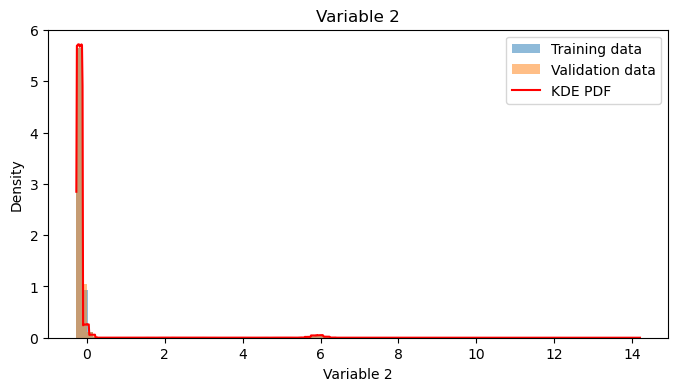

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 3')

(array([4.08788067e+00, 1.79160632e+00, 7.45478589e-01, 3.24913195e-01,
        2.03953699e-02, 1.62006700e-02, 1.33621839e-02, 7.65478396e-03,
        3.50789930e-03, 1.69961416e-03, 1.20842132e-03, 1.11279085e-03,
        9.91079355e-04, 9.43264123e-04, 9.08490190e-04, 8.51979765e-04,
        9.17183087e-04, 1.14321775e-03, 1.24754609e-03, 1.66049117e-03,
        2.26904815e-03, 3.57744565e-03, 4.15993592e-03, 4.18600262e-03,
        3.56875198e-03, 3.69481021e-03, 3.77306623e-03, 3.70785071e-03,
        4.07733173e-03, 3.95998080e-03, 3.64699502e-03, 3.83825578e-03,
        4.09906591e-03, 4.46420010e-03, 4.80326979e-03, 5.17273429e-03,
        4.77282542e-03, 4.13820167e-03, 3.71654438e-03, 3.44704058e-03,
        3.29490134e-03, 3.16884311e-03, 4.62070207e-03, 7.35919256e-03,
        1.18842484e-02, 1.67353744e-02, 1.87739827e-02, 1.41446028e-02,
        9.38481792e-03, 4.26859250e-03, 1.79959610e-03, 6.95493686e-04,
        4.52070896e-04, 2.21689375e-04, 1.65179750e-04, 1.564860

(array([4.09666082e+00, 1.93224289e+00, 8.07568845e-01, 3.82226475e-01,
        2.14359213e-02, 1.58633953e-02, 1.40736789e-02, 9.92479089e-03,
        3.62010977e-03, 2.52187084e-03, 1.34228789e-03, 9.35533986e-04,
        1.13891094e-03, 1.58633740e-03, 9.35533986e-04, 8.13507814e-04,
        9.35533986e-04, 8.13507814e-04, 8.54181676e-04, 1.46431406e-03,
        2.23714649e-03, 2.60322035e-03, 3.78281133e-03, 4.92172227e-03,
        3.94551290e-03, 3.98618829e-03, 3.49807734e-03, 3.17268047e-03,
        3.13200508e-03, 3.53875266e-03, 3.86416211e-03, 2.92862813e-03,
        4.39293434e-03, 4.79969610e-03, 4.84037149e-03, 4.31159141e-03,
        6.14196202e-03, 4.18956524e-03, 5.08442384e-03, 4.10821446e-03,
        3.98618829e-03, 3.29470665e-03, 3.45740821e-03, 4.27090074e-03,
        4.23024063e-03, 9.39601525e-03, 1.33415281e-02, 1.84666274e-02,
        1.85073028e-02, 1.57413762e-02, 9.23331368e-03, 3.74213594e-03,
        1.30160785e-03, 5.69455470e-04, 5.69455470e-04, 1.627015

Text(0.5, 0, 'Variable 3')

Text(0, 0.5, 'Density')

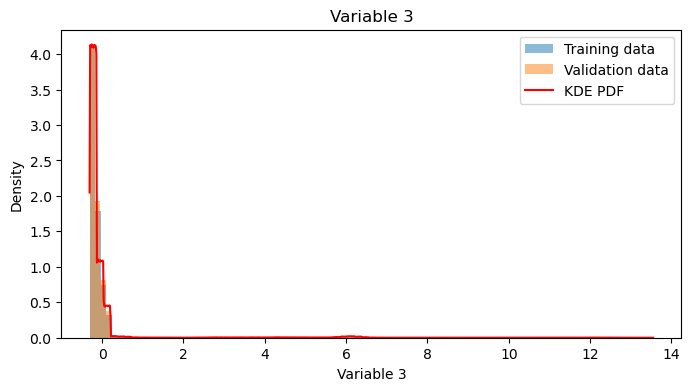

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 4')

(array([3.51547263e+00, 3.50474841e+00, 3.51288712e+00, 2.14337074e+00,
        1.93454636e+00, 1.94933261e+00, 4.99163691e-01, 7.99563536e-03,
        7.64593167e-03, 7.94795392e-03, 7.96384983e-03, 7.67772349e-03,
        7.74130712e-03, 7.55055622e-03, 8.29765737e-03, 7.77310505e-03,
        7.99564793e-03, 8.52019990e-03, 7.32800775e-03, 8.07512753e-03,
        7.93206425e-03, 8.52019990e-03, 8.63147117e-03, 7.97975201e-03,
        8.23408674e-03, 7.75719693e-03, 7.88436409e-03, 7.82079281e-03,
        8.34535818e-03, 7.72539299e-03, 8.83813171e-03, 1.24306097e-02,
        1.39248262e-02, 1.30982384e-02, 3.24593672e-02, 4.64001915e-02,
        4.77354488e-02, 5.80358226e-02, 6.73192226e-02, 6.92426290e-02,
        5.28698311e-02, 2.23973518e-02, 2.09189654e-02, 1.76126797e-02,
        2.24132477e-03, 2.14594250e-03, 2.27311661e-03, 2.81357790e-03,
        2.49566342e-03, 2.59103502e-03, 6.46165097e-02, 6.49984183e-02,
        6.64767389e-02, 5.63112978e-01, 6.45994307e-01, 6.446908

(array([3.50615903e+00, 3.47075197e+00, 3.53827465e+00, 2.15825382e+00,
        1.90524386e+00, 1.98093183e+00, 5.15624270e-01, 7.16742104e-03,
        9.46100323e-03, 9.60435176e-03, 8.88760209e-03, 7.31076946e-03,
        7.59747229e-03, 9.89104883e-03, 7.59746631e-03, 8.74425367e-03,
        7.16742104e-03, 6.88072420e-03, 7.31078098e-03, 8.45755683e-03,
        1.10378284e-02, 7.59746631e-03, 7.31076946e-03, 7.31076946e-03,
        7.59747828e-03, 7.74081473e-03, 7.59747828e-03, 7.74081473e-03,
        9.17429893e-03, 7.59746631e-03, 6.45067894e-03, 1.24713126e-02,
        1.47648873e-02, 1.53382810e-02, 2.95297747e-02, 4.37212684e-02,
        4.44380105e-02, 5.92030844e-02, 7.11008167e-02, 6.33600020e-02,
        5.47590968e-02, 2.19323084e-02, 2.19323084e-02, 1.74885073e-02,
        1.00343895e-03, 2.58027158e-03, 3.01031684e-03, 2.15022631e-03,
        3.44037836e-03, 1.86352947e-03, 5.66226262e-02, 6.62269704e-02,
        6.47930778e-02, 5.02296033e-01, 6.46931423e-01, 6.530954

Text(0.5, 0, 'Variable 4')

Text(0, 0.5, 'Density')

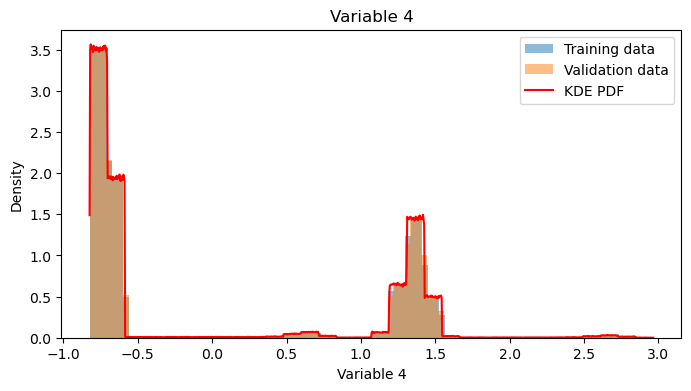

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Variable 5')

(array([0.29103934, 0.28976919, 0.28785526, 0.28884801, 0.29119594,
        0.28865563, 0.28867303, 0.28982139, 0.2894734 , 0.29091755,
        0.28950919, 0.28808046, 0.29003118, 0.28980399, 0.28818584,
        0.28926461, 0.28703749, 0.28886442, 0.28740287, 0.28975279,
        0.28821965, 0.28912641, 0.28808145, 0.29053476, 0.28917761,
        0.28766386, 0.28719457, 0.28882962, 0.28802975, 0.28789005,
        0.28921241, 0.28815105, 0.28808145, 0.29015197, 0.28869043,
        0.28835984, 0.28832603, 0.2894212 , 0.28580213, 0.289456  ,
        0.28841204, 0.28639371, 0.28627191, 0.289196  , 0.28733327,
        0.28827284, 0.28989098, 0.28811625, 0.28893402, 0.28804665,
        0.28914281, 0.28802925, 0.28742126, 0.2867417 , 0.28917761,
        0.29074355, 0.28966479, 0.28912641, 0.28875903, 0.28961359,
        0.28809786, 0.28853482, 0.28815005, 0.28902201, 0.28839563,
        0.28860244, 0.28601191, 0.28933321, 0.28752566, 0.28935061,
        0.28677748, 0.29058596, 0.28881322, 0.28

(array([0.29033032, 0.27983834, 0.28422304, 0.29033032, 0.2870408 ,
        0.28328444, 0.28845016, 0.29064351, 0.28281367, 0.2911133 ,
        0.27936854, 0.29033032, 0.29220948, 0.28328346, 0.28845115,
        0.28124674, 0.30144972, 0.28954633, 0.29408864, 0.29017372,
        0.28751157, 0.29831675, 0.28876435, 0.29158309, 0.27874168,
        0.28766817, 0.29471502, 0.28124771, 0.29314855, 0.28751157,
        0.28892094, 0.28954733, 0.28328346, 0.28030813, 0.29455843,
        0.28845115, 0.30097889, 0.29001612, 0.28688519, 0.28907754,
        0.28688519, 0.30505041, 0.29189628, 0.28657199, 0.28860775,
        0.28390985, 0.29064351, 0.28923414, 0.28594462, 0.28876435,
        0.28344006, 0.28578901, 0.29675078, 0.29753376, 0.28062132,
        0.28234388, 0.2721651 , 0.28015056, 0.28391083, 0.29299145,
        0.29268027, 0.28751058, 0.29925736, 0.28923314, 0.29534039,
        0.27921291, 0.30645872, 0.28578999, 0.28845016, 0.29080111,
        0.29988168, 0.27764694, 0.29236507, 0.28

Text(0.5, 0, 'Variable 5')

Text(0, 0.5, 'Density')

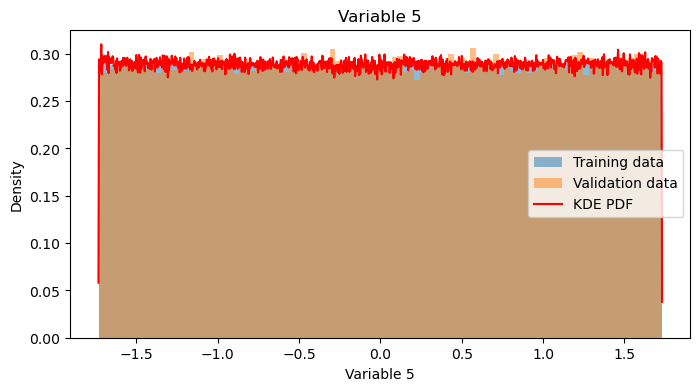

In [31]:
for i in range(d):
  plt.figure(figsize=(8, 4))
  plt.title(f"Variable {i}")
  plt.hist(
    x_trn[:, i], bins=100, density=True, alpha=0.5, label="Training data"
  )
  plt.hist(
    x_val[:, i], bins=100, density=True, alpha=0.5, label="Validation data"
  )
  x = np.linspace(
    margins[i].grid_points.min(), margins[i].grid_points.max(), 1000
  )
  plt.plot(x, margins[i].pdf(x), label="KDE PDF", color="red")
  plt.xlabel(f"Variable {i}")
  plt.ylabel("Density")
  plt.legend()
  plt.show()

In [23]:
# i = 0
# multiplier = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# val_loglik = []
# for m in multiplier:
#   margins = [
#     pv.Kde1d(**margins_controls[i]["kde"], degree=0, multiplier=m)
#     for i in range(d)
#   ]
#   for i in range(d):
#     margins[i].fit(x_trn[:, i])

#   margins_loglik = np.column_stack(
#     [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
#   )
#   val_loglik.append(margins_loglik.mean(axis=0))

# val_loglik = np.array(val_loglik)

# plt.figure(figsize=(10, 6))
# plt.plot(multiplier, val_loglik[:, 0], label="x1")
# plt.plot(multiplier, val_loglik[:, 1], label="x2")
# plt.plot(multiplier, val_loglik[:, 2], label="x3")
# plt.plot(multiplier, val_loglik[:, 3], label="x4")
# plt.plot(multiplier, val_loglik[:, 4], label="x5")
# plt.plot(multiplier, val_loglik[:, 5], label="x6")
# plt.xscale("log")
# plt.xlabel("Multiplier")
# plt.ylabel("Log-likelihood")
# plt.title("Validation log-likelihood for different multipliers")
# plt.legend()
# plt.grid()
# plt.show()

In [24]:
sample_size_fit = 200000
sample_size_select = 2000
nonparametric_grid_size_fit = grid_size_2d(sample_size_fit, h=None, c=0.7)
nonparametric_grid_size_select = grid_size_2d(sample_size_select, h=None, c=0.7)
num_threads = 6
controls_fit = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=nonparametric_grid_size_fit,
)
controls_select = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=nonparametric_grid_size_select,
)

In [25]:
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_fit, replace=False), :
]
cop = pv.Vinecop.from_data(u_trn_sub, controls=controls_fit)

In [26]:
# Create an instance of VinesForest
forest = VinesForest(controls=controls_select)

# Subsampled data for training
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_select, replace=False), :
]
u_val_sub = u_val[
  np.random.choice(u_val.shape[0], sample_size_select, replace=False), :
]
forest.fit(u_trn_sub, u_val_sub)

In [28]:
best_vine = forest.logliks_forest.mean(axis=1).argmax()
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size_fit, replace=False), :
]
cop2 = forest.vines[best_vine]
cop2.from_data(
  u_trn_sub,
  structure=cop2.structure,
  controls=controls_fit,
)
np.log(cop2.pdf(u_tst)).mean()

<pyvinecopulib.Vinecop> Vinecop model with 6 variables
tree edge conditioned variables conditioning variables var_types family rotation   parameters    df   tau 
   1    1                  6, 2                             c, c    TLL          [30x30 grid] 411.9 -0.12 
   1    2                  1, 5                             c, c    TLL          [30x30 grid] 413.8  0.39 
   1    3                  2, 5                             c, c    TLL          [30x30 grid] 416.2 -0.12 
   1    4                  3, 5                             c, c    TLL          [30x30 grid] 502.9  0.04 
   1    5                  4, 5                             c, c    TLL          [30x30 grid] 477.7  0.02 
   2    1                  6, 5                      2      c, c    TLL          [30x30 grid] 469.1  0.04 
   2    2                  1, 4                      5      c, c    TLL          [30x30 grid] 366.3  0.13 
   2    3                  2, 4                      5      c, c    TLL          [30x30 g

np.float64(0.7147309262029685)

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Log-Likelihood of Test Data')

(array([2.00000e+00, 2.00000e+00, 3.00000e+00, 1.00000e+01, 1.01000e+02,
        4.25000e+02, 1.26200e+03, 6.46200e+03, 3.01600e+04, 1.66501e+05]),
 array([-13.40570643, -12.13283935, -10.85997226,  -9.58710518,
         -8.3142381 ,  -7.04137102,  -5.76850394,  -4.49563686,
         -3.22276978,  -1.9499027 ,  -0.67703562]),
 <BarContainer object of 10 artists>)

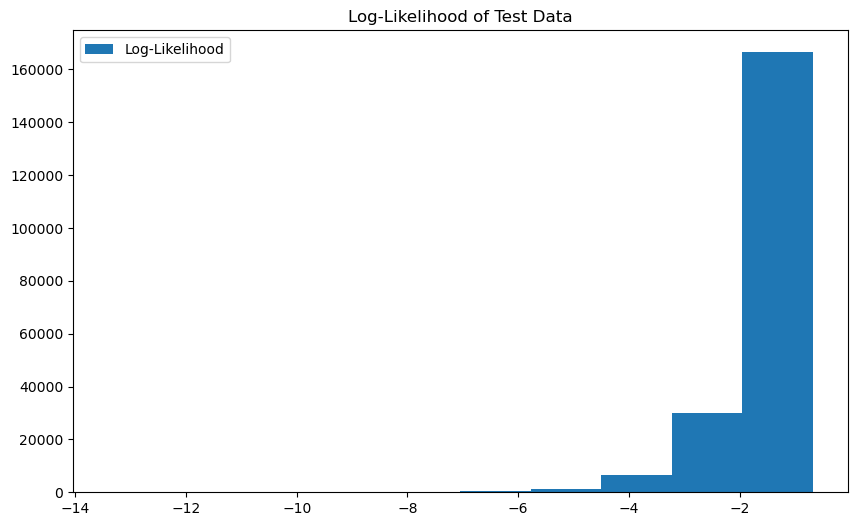

In [39]:
plt.figure(figsize=(10, 6))
plt.title("Log-Likelihood of Test Data")
plt.hist(margins_loglik[:, 1], label="Log-Likelihood")
plt.legend()
plt.show()

In [ ]:
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])
margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]
)
cop_loglik = np.log(cop.pdf(u_tst)).mean()
print(
  cop_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop_loglik,
)

cop2_loglik = np.log(cop2.pdf(u_tst)).mean()
print(
  cop2_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop2_loglik,
)

0.935617196034843 -0.8773928531519191 0.058224342882923885
0.9865773291374371 -0.8773928531519191 0.10918447598551806


<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 0')

(array([1.91529174, 1.74712059, 1.49998084, 1.201359  , 1.32218206,
        1.19781294, 1.17067552, 1.03353694, 1.0942057 , 0.96682335,
        0.88724843, 0.84864605, 0.85535232, 0.84690058, 0.85816344,
        0.75564022, 0.9108398 , 0.81281804, 0.87684912, 0.87510366,
        0.83295522, 0.81377346, 0.84276658, 0.85496648, 0.85052013,
        0.84627589, 0.85555443, 0.85072224, 0.85180627, 0.84579818]),
 array([0.0039237 , 0.03712237, 0.07032104, 0.10351971, 0.13671838,
        0.16991704, 0.20311571, 0.23631438, 0.26951305, 0.30271172,
        0.33591039, 0.36910906, 0.40230773, 0.4355064 , 0.46870507,
        0.50190374, 0.53510241, 0.56830108, 0.60149975, 0.63469841,
        0.66789708, 0.70109575, 0.73429442, 0.76749309, 0.80069176,
        0.83389043, 0.8670891 , 0.90028777, 0.93348644, 0.96668511,
        0.99988378]),
 <BarContainer object of 30 artists>)

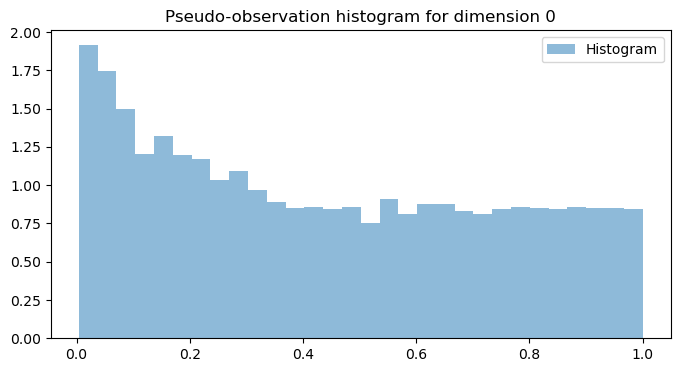

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 1')

(array([1.00159413, 1.00183232, 0.99983518, 0.99213977, 1.0100774 ,
        0.99093049, 0.99785636, 0.99897403, 1.01509774, 1.01504277,
        1.0044341 , 0.99087552, 1.01458471, 0.99475987, 0.97748185,
        1.03147797, 0.98970289, 1.01810261, 0.97903925, 1.00349966,
        0.99322079, 1.02506513, 0.97390898, 1.00390275, 0.99943209,
        1.01832248, 0.99913893, 0.99067398, 1.00109942, 1.00608312]),
 array([1.56063142e-04, 3.34470212e-02, 6.67379793e-02, 1.00028937e-01,
        1.33319895e-01, 1.66610854e-01, 1.99901812e-01, 2.33192770e-01,
        2.66483728e-01, 2.99774686e-01, 3.33065644e-01, 3.66356602e-01,
        3.99647560e-01, 4.32938518e-01, 4.66229476e-01, 4.99520434e-01,
        5.32811392e-01, 5.66102350e-01, 5.99393309e-01, 6.32684267e-01,
        6.65975225e-01, 6.99266183e-01, 7.32557141e-01, 7.65848099e-01,
        7.99139057e-01, 8.32430015e-01, 8.65720973e-01, 8.99011931e-01,
        9.32302889e-01, 9.65593847e-01, 9.98884805e-01]),
 <BarContainer object of 30 

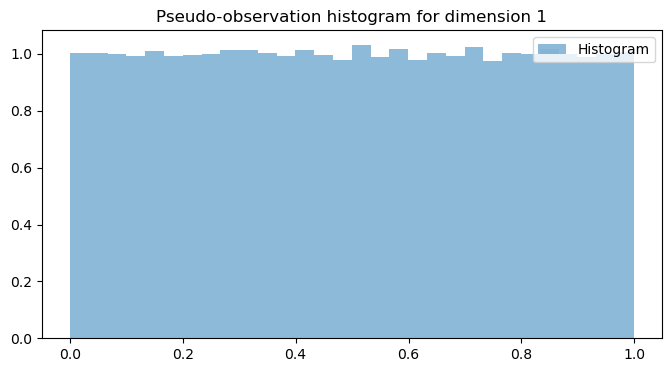

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 2')

(array([27.68365708,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.25448784,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.28054204,  0.        ,  0.05518075,  0.09169797,
         0.09040956,  0.02825299,  0.07735981,  0.        ,  0.21838547,
         0.        ,  0.23855828,  0.        ,  0.09455088,  0.0619173 ]),
 array([0.        , 0.03314002, 0.06628003, 0.09942005, 0.13256007,
        0.16570008, 0.1988401 , 0.23198012, 0.26512013, 0.29826015,
        0.33140017, 0.36454018, 0.3976802 , 0.43082022, 0.46396023,
        0.49710025, 0.53024027, 0.56338028, 0.5965203 , 0.62966032,
        0.66280033, 0.69594035, 0.72908037, 0.76222038, 0.7953604 ,
        0.82850042, 0.86164043, 0.89478045, 0.92792047, 0.96106048,
        0.9942005 ]),
 <BarContainer object of 30 artists>)

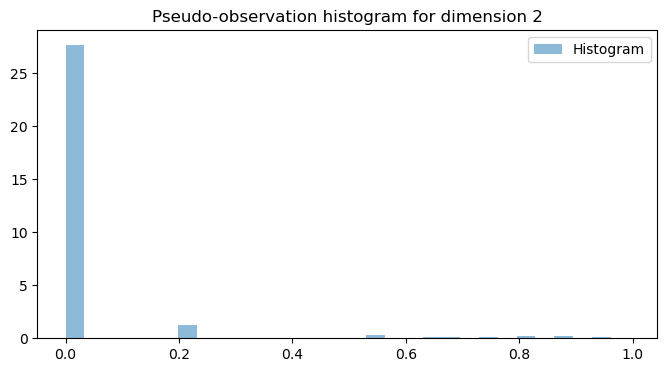

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 3')

(array([21.03420471,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  8.96579531]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

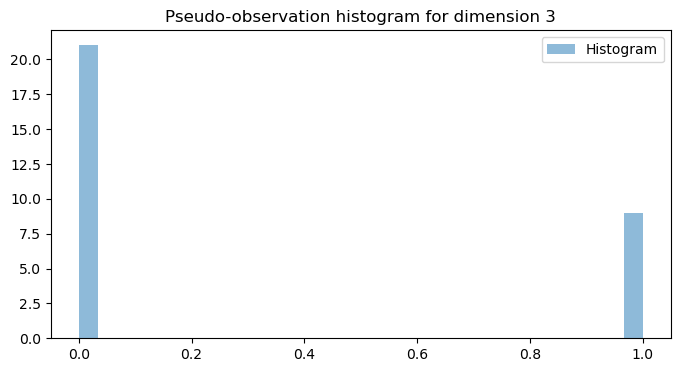

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 4')

(array([92.0416621 ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , 50.97220069,
         0.        ,  0.        ,  0.        ,  0.20934112,  0.        ,
         0.20866626,  0.20650671,  0.        ,  0.20677666,  0.21271541,
         0.42313631,  0.2185192 ,  1.57754933,  1.8024122 ,  0.63288234,
        18.68818276, 51.16912441,  0.65852697,  0.31407917,  1.73357662]),
 array([0.        , 0.00451925, 0.00903849, 0.01355774, 0.01807698,
        0.02259623, 0.02711547, 0.03163472, 0.03615397, 0.04067321,
        0.04519246, 0.0497117 , 0.05423095, 0.0587502 , 0.06326944,
        0.06778869, 0.07230793, 0.07682718, 0.08134642, 0.08586567,
        0.09038492, 0.09490416, 0.09942341, 0.10394265, 0.1084619 ,
        0.11298115, 0.11750039, 0.12201964, 0.12653888, 0.13105813,
        0.13557737]),
 <BarContainer object of 30 artists>)

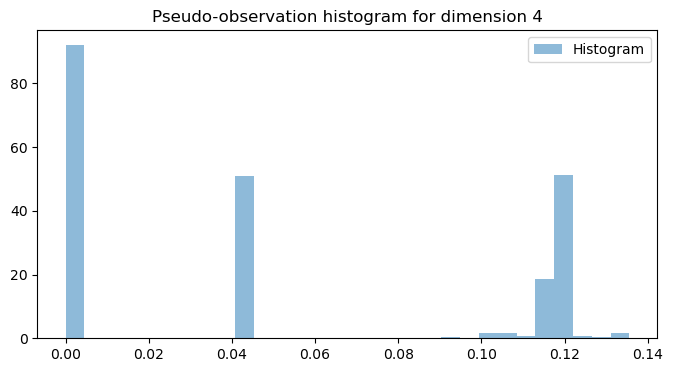

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 5')

(array([1.00471264, 0.99913141, 1.00215077, 0.99929611, 0.99865564,
        0.99953399, 0.99882033, 1.00077833, 0.99874713, 1.00050385,
        1.00167499, 0.99887523, 0.99561798, 1.00044895, 0.99988168,
        0.99863734, 1.00196778, 1.00253505, 0.99753939, 0.99790537,
        0.99828965, 1.00090643, 0.99993657, 0.99880203, 1.00255335,
        0.99891182, 1.00024766, 0.9993327 , 0.99865564, 1.00495053]),
 array([3.52466751e-09, 3.33333365e-02, 6.66666695e-02, 1.00000002e-01,
        1.33333335e-01, 1.66666668e-01, 2.00000001e-01, 2.33333334e-01,
        2.66666667e-01, 3.00000000e-01, 3.33333333e-01, 3.66666666e-01,
        3.99999999e-01, 4.33333332e-01, 4.66666665e-01, 4.99999998e-01,
        5.33333331e-01, 5.66666664e-01, 5.99999997e-01, 6.33333330e-01,
        6.66666663e-01, 6.99999996e-01, 7.33333329e-01, 7.66666662e-01,
        7.99999995e-01, 8.33333328e-01, 8.66666661e-01, 8.99999994e-01,
        9.33333327e-01, 9.66666660e-01, 9.99999993e-01]),
 <BarContainer object of 30 

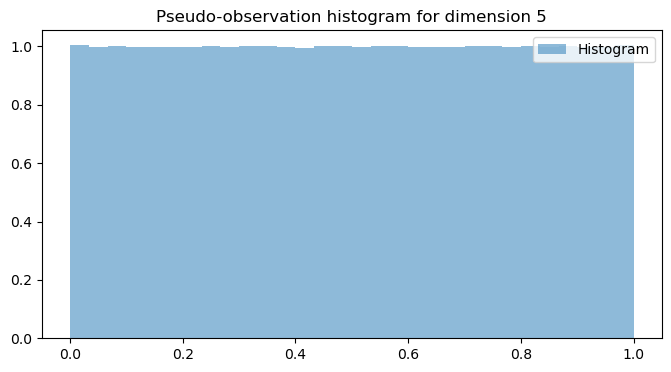

In [ ]:
for i, model in enumerate(margins):
  plt.figure(figsize=(8, 4))
  plt.title(f"Pseudo-observation histogram for dimension {i}")
  plt.hist(u_trn[:, i], bins=30, density=True, alpha=0.5, label="Histogram")
  plt.legend()
  plt.show()